In [ ]:
import argparse
import json
from pathlib import Path
import os
import time
from datetime import timedelta
import sys
sys.path.append("../..")


import numpy as np
import csv
import torch
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, ThreadDataLoader
from monai.data.utils import pad_list_data_collate
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import random

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler

from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist

import utils.custom_transforms as custom_transforms
from utils.utils import *
import AnoDDPM.simplex as simplex
import utils.simplex_ddpm as simplex_ddpm

import matplotlib.pyplot as plt

from datasets import anomaly_datasets


In [ ]:


@torch.no_grad()
def my_sample(args, model, device, image, infer_scheduler, timesteps, return_intermediates=False):
    
    simplexObj = simplex.Simplex_CLASS()

    if args.noise["type"] == "simplex":
        noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape, normalize=args.noise["normalize"]).to(device)
    if args.noise["type"] == "gaussian":
        noise = torch.randn(image.shape).to(device)
    

    if timesteps >= infer_scheduler.num_train_timesteps:
        dtprint(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)

    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO


    intermediates = []
    intermediates_step = 20

    for t in range(timesteps, 0, -1): # va de timesteps à 0
        
        model_output = model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #print(model_output.shape)
        
        image, _ = infer_scheduler.step(model_output, t, image)
    
        if (t== timesteps-1 or t%intermediates_step == 0) and return_intermediates:
            intermediates.append(image)

    if return_intermediates:
        return image, intermediates
    else:
        return image




In [ ]:
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
#ROOT_DIR = "/home/fehrdelt/bettik/"

In [ ]:

def compute_loss_simplex(images, simplexObj, model, inferer, num_timesteps, normalize, device):
    with autocast("cuda", enabled=True):

        # Generate random noise
        if normalize == False:
            noise = simplex_ddpm.generate_simplex_noise(simplexObj, images.shape, normalize=False).to(device, non_blocking=True) #TODO: check non_blocking (21/09/2025)
        else:
            noise = simplex_ddpm.generate_simplex_noise(simplexObj, images.shape, normalize=True).to(device, non_blocking=True) #TODO: check non_blocking (21/09/2025) 

        # Create timesteps
        timesteps = torch.randint(0, num_timesteps, (images.shape[0],), device=images.device).long()

        # Get model prediction
        noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)

        loss = F.mse_loss(noise_pred.float(), noise.float())

        return loss

def compute_loss_gaussian(images, model, inferer, num_timesteps, device):
    with autocast("cuda", enabled=True):

        # Generate random noise
        noise = torch.randn_like(images).to(device, non_blocking=True) #TODO: check non_blocking (21/09/2025)

        # Create timesteps
        timesteps = torch.randint(0, num_timesteps, (images.shape[0],), device=images.device).long()

        # Get model prediction
        noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)

        loss = F.mse_loss(noise_pred.float(), noise.float())

        return loss

In [ ]:
config_dict = json.load(open(ROOT_DIR+"AnoDiffExperiments/experiment_4/exp_4_0/config.json", "r"))
args = argparse.Namespace(**config_dict)


In [ ]:

ROOT_DIR = args.root_dir
EXPERIMENT_NAME = args.experiment_name
SUB_EXPERIMENT_NAME = args.sub_experiment_name
MODELS_DIR = ROOT_DIR+f"AnoDiffExperiments/{EXPERIMENT_NAME}/{SUB_EXPERIMENT_NAME}/models/"
os.makedirs(MODELS_DIR, exist_ok=True)

rank = 0
world_size = 1
device = 0

torch.cuda.set_device(device)
print(f"Using {device}")

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)


Using 0


In [7]:

# dataset 1: adc

exclude_csv_adc = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[0]['name']}/exclude.csv")
exclude_list = []
if os.path.exists(exclude_csv_adc):
    with open(exclude_csv_adc, mode="r") as file:
        reader = csv.reader(file)
        for line in reader:
                exclude_list.append(line[0])

train_csv_adc = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[0]['name']}/train.csv")
train_images_path_adc = []

with open(train_csv_adc, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            train_images_path_adc.append(ROOT_DIR+line[0])

val_csv_adc = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[0]['name']}/val.csv")
val_images_path_adc = []

with open(val_csv_adc, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            val_images_path_adc.append(ROOT_DIR+line[0])

test_csv_adc = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[0]['name']}/test.csv")
test_images_path_adc = []

with open(test_csv_adc, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            test_images_path_adc.append(ROOT_DIR+line[0])

# dataset 2: flair

exclude_csv_flair = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[1]['name']}/exclude.csv")
exclude_list = []
if os.path.exists(exclude_csv_flair):
    with open(exclude_csv_flair, mode="r") as file:
        reader = csv.reader(file)
        for line in reader:
                exclude_list.append(line[0])

train_csv_flair = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[1]['name']}/train.csv")
train_images_path_flair = []

with open(train_csv_flair, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            train_images_path_flair.append(ROOT_DIR+line[0])

val_csv_flair = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[1]['name']}/val.csv")
val_images_path_flair = []

with open(val_csv_flair, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            val_images_path_flair.append(ROOT_DIR+line[0])

test_csv_flair = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[1]['name']}/test.csv")
test_images_path_flair = []

with open(test_csv_flair, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            test_images_path_flair.append(ROOT_DIR+line[0])

# dataset 3: t1

exclude_csv_t1 = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[2]['name']}/exclude.csv")
exclude_list = []
if os.path.exists(exclude_csv_t1):
    with open(exclude_csv_t1, mode="r") as file:
        reader = csv.reader(file)
        for line in reader:
                exclude_list.append(line[0])

train_csv_t1 = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[2]['name']}/train.csv")
train_images_path_t1 = []

with open(train_csv_t1, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            train_images_path_t1.append(ROOT_DIR+line[0])

val_csv_t1 = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[2]['name']}/val.csv")
val_images_path_t1 = []

with open(val_csv_t1, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            val_images_path_t1.append(ROOT_DIR+line[0])

test_csv_t1 = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.datasets[2]['name']}/test.csv")
test_images_path_t1 = []

with open(test_csv_t1, mode='r') as file:
    reader = csv.reader(file)
    for line in reader:
        if line[0] not in exclude_list:
            test_images_path_t1.append(ROOT_DIR+line[0])



batch_size = args.datasets[0]["batch_size"]
num_workers = args.datasets[0]["num_workers"]

In [34]:
all_adc_paths = sorted(train_images_path_adc + val_images_path_adc + test_images_path_adc)

all_flair_paths = sorted(train_images_path_flair + val_images_path_flair + test_images_path_flair)

all_t1_paths = sorted(train_images_path_t1 + val_images_path_t1 + test_images_path_t1)


all_adc_imagenames = [path.split("/")[-1] for path in all_adc_paths]
all_flair_imagenames = [path.split("/")[-1] for path in all_flair_paths]
all_t1_imagenames = [path.split("/")[-1] for path in all_t1_paths]

all_adc_imagenames_final = ["_".join(name.split("_")[:2]) for name in all_adc_imagenames]
all_flair_imagenames_final = ["_".join(name.split("_")[:2]) for name in all_flair_imagenames]
all_t1_imagenames_final = ["_".join(name.split("_")[:2]) for name in all_t1_imagenames]

In [35]:
print(len(train_images_path_adc))
print(len(val_images_path_adc))
print(len(all_adc_paths))

568
71
711


In [36]:
print(all_adc_imagenames_final[:5])
print(all_flair_imagenames_final[:5])
print(all_t1_imagenames_final[:5])

['sub-1003_ses-wave1', 'sub-1003_ses-wave2', 'sub-1003_ses-wave3', 'sub-1007_ses-wave1', 'sub-1007_ses-wave2']
['sub-1003_ses-wave1', 'sub-1003_ses-wave2', 'sub-1003_ses-wave3', 'sub-1007_ses-wave1', 'sub-1007_ses-wave2']
['sub-1003_ses-wave1', 'sub-1003_ses-wave2', 'sub-1003_ses-wave3', 'sub-1007_ses-wave1', 'sub-1007_ses-wave2']


In [37]:
intersection = list(set(all_adc_imagenames_final) & set(all_flair_imagenames_final) & set(all_t1_imagenames_final))
print(f"Number of common images: {len(intersection)}")

Number of common images: 682


In [38]:
train_imagenames = intersection[:int(len(intersection)*0.8)]
val_imagenames = intersection[int(len(intersection)*0.8):int(len(intersection)*0.9)]
test_imagenames = intersection[int(len(intersection)*0.9):]

In [52]:
train_images_adc = []
train_images_flair = []
train_images_t1 = []

for imagename in train_imagenames:
    train_images_adc.append(ROOT_DIR+f"datasets/final_adc_dataset_small/Dallas_registered/"+imagename+"_ADC.nii.gz")
    train_images_flair.append(ROOT_DIR+f"datasets/final_flair_dataset_small/dallas_registered/"+imagename+"_acq-FLAIR_run-1_T2w.nii.gz")
    train_images_t1.append(ROOT_DIR+f"datasets/final_t1_dataset_small/dallas_registered/"+imagename+"_acq-MPRAGE_run-1_T1w.nii.gz")

val_images_adc = []
val_images_flair = []
val_images_t1 = []

for imagename in val_imagenames:
    val_images_adc.append(ROOT_DIR+f"datasets/final_adc_dataset_small/Dallas_registered/"+imagename+"_ADC.nii.gz")
    val_images_flair.append(ROOT_DIR+f"datasets/final_flair_dataset_small/dallas_registered/"+imagename+"_acq-FLAIR_run-1_T2w.nii.gz")
    val_images_t1.append(ROOT_DIR+f"datasets/final_t1_dataset_small/dallas_registered/"+imagename+"_acq-MPRAGE_run-1_T1w.nii.gz")

In [53]:
print(val_images_adc[:5])
print(val_images_flair[:5])
print(val_images_t1[:5])

['/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas_registered/sub-2748_ses-wave2_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas_registered/sub-153_ses-wave1_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas_registered/sub-1421_ses-wave1_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas_registered/sub-474_ses-wave1_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas_registered/sub-1153_ses-wave3_ADC.nii.gz']
['/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_flair_dataset_small/dallas_registered/sub-2748_ses-wave2_acq-FLAIR_run-1_T2w.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_flair_dataset_small/dallas_registered/sub-153_ses-wave1_acq-FLAIR_run-1_T2w.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_flair_dataset_small/dallas_registered/sub-1421_se

In [54]:
print(len(val_images_adc))
print(len(val_images_flair))
print(len(val_images_t1))

68
68
68


In [55]:
print(len(train_images_adc))
print(len(train_images_flair))
print(len(train_images_t1))

545
545
545


In [63]:

# TODO
NB_IMAGES_TO_LOAD = 64

train_datalist = [
    {"adc": adc_path, "flair": flair_path, "t1": t1_path}
    for adc_path, flair_path, t1_path in zip(train_images_adc[:NB_IMAGES_TO_LOAD], train_images_flair[:NB_IMAGES_TO_LOAD], train_images_t1[:NB_IMAGES_TO_LOAD])
]
val_datalist = [
    {"adc": adc_path, "flair": flair_path, "t1": t1_path}
    for adc_path, flair_path, t1_path in zip(val_images_adc[:NB_IMAGES_TO_LOAD], val_images_flair[:NB_IMAGES_TO_LOAD], val_images_t1[:NB_IMAGES_TO_LOAD])
]


# train transforms
train_transforms_def = define_instance(args, "train_transforms")

train_transforms = transforms.Compose([
    *train_transforms_def.transforms,
    transforms.Lambda(func=lambda x: x["image"]),
])

train_ds = CacheDataset(data=train_datalist, transform=train_transforms)


# val transforms
val_transforms_def = define_instance(args, "val_transforms")


val_transforms = transforms.Compose([
    *val_transforms_def.transforms,
    transforms.Lambda(func=lambda x: x["image"]),
])

val_ds = CacheDataset(data=val_datalist, transform=val_transforms)



train_sampler = None
val_sampler = None


train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, sampler=train_sampler
)
val_loader = DataLoader( # smaller batch size for validation since we are validating on full volumes
    val_ds, batch_size=5, shuffle=False, num_workers=num_workers, pin_memory=True, sampler=val_sampler
)

Loading dataset: 100%|██████████| 64/64 [01:32<00:00,  1.44s/it]


In [64]:



model = define_instance(args, "network_def").to(device)

if args.noise["type"] == "simplex":
    simplexObj = simplex.Simplex_CLASS()
    scheduler = simplex_ddpm.SimplexDDPMScheduler(num_train_timesteps=args.noise["num_timesteps_full_noise"], schedule=args.noise["schedule"], octaves=args.noise["simplex_octaves"], persistence=args.noise["simplex_persistence"], frequency=args.noise["simplex_frequency"], normalize=args.noise["normalize"])

elif args.noise["type"] == "gaussian":
    scheduler = DDPMScheduler(num_train_timesteps=args.noise["num_timesteps_full_noise"], schedule=args.noise["schedule"])

if args.diffusion_train["optimizer"]["type"] == "Adam":
    optimizer = torch.optim.Adam(params=model.parameters(), lr=args.diffusion_train["optimizer"]["lr"] * world_size)

if args.diffusion_train["lr_scheduler"]!= "none":
    
    if args.diffusion_train["lr_scheduler"] == "MultiStepLR":
        lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=args.diffusion_train["lr_scheduler_milestones"],
        gamma=0.1)

last_epoch = 0
best_val_loss = np.inf
best_val_epoch = 0

if args.diffusion_train.get("resume_checkpoint", False) == True:

    last_epoch = args.diffusion_train.get("last_checkpoint_epoch", None)
    best_val_loss = args.diffusion_train.get("last_best_val_loss", np.inf)
    best_val_epoch = args.diffusion_train.get("last_checkpoint_epoch", 0)
    model.load_state_dict(torch.load(MODELS_DIR+f"{SUB_EXPERIMENT_NAME}_best_model.pth", map_location=f"cuda:{device}"))
    

inferer = DiffusionInferer(scheduler)


if rank==0:
    os.makedirs(ROOT_DIR+f"AnoDiffExperiments/tensorboard/{SUB_EXPERIMENT_NAME}", exist_ok=True)
    writer = SummaryWriter(ROOT_DIR+f"AnoDiffExperiments/tensorboard/{SUB_EXPERIMENT_NAME}")

max_epochs = args.diffusion_train["max_epochs"]
val_interval = args.diffusion_train["val_interval"]


scaler = GradScaler("cuda")


**TODO Faut que ça fasse le scaleintensity ranged histogram sur chaque contraste séparément, pas tout d'un coup**

-> faire un ScaleIntensityFromHistogramPeakd avec dictionnaire pour chaque contraste\
-> faire un Get2DSliceFromIndexes avec dico aussi\
et seulement ensuite mettre la concaténation pour faire 2 channel

Batch shape: torch.Size([16, 3, 128, 128])
First image shape: torch.Size([3, 128, 128])


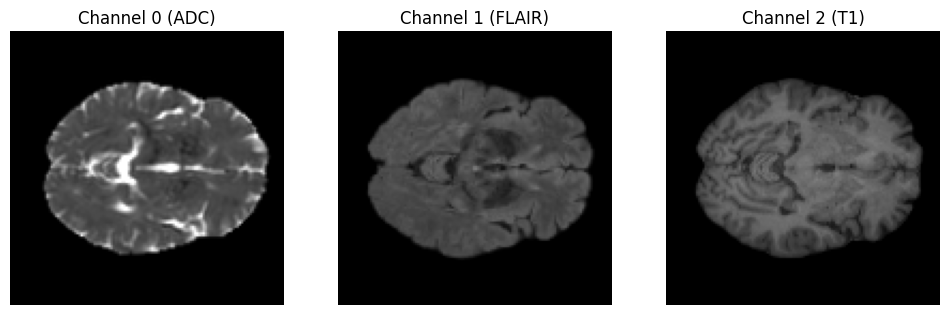

In [67]:


batch = next(iter(train_loader))
print("Batch shape:", batch.shape)
first_image = batch[0]
print("First image shape:", first_image.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(first_image[0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Channel 0 (ADC)")
axes[0].axis("off")
axes[1].imshow(first_image[1].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Channel 1 (FLAIR)")
axes[1].axis("off")
axes[2].imshow(first_image[2].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Channel 2 (T1)")
axes[2].axis("off")
plt.axis("off")
plt.show()

### Launch training loop

In [68]:



for epoch in range(last_epoch, max_epochs):
    model.train()
    if rank==0 and args.diffusion_train["lr_scheduler"] != "none":
        lr_scheduler.step()


    epoch_loss = 0
    #progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=70)
    #progress_bar.set_description(f"Epoch {epoch}")

    #for step, batch in progress_bar:
    for step, batch in enumerate(train_loader):
        images = batch.to(device, non_blocking=True) #TODO: check non_blocking (21/09/2025)
        optimizer.zero_grad(set_to_none=True)

        if args.noise["type"] == "simplex":
            loss = compute_loss_simplex(images, simplexObj, model, inferer, int(args.noise["noise_rate_train_and_infer"]*args.noise["num_timesteps_full_noise"]), normalize=args.noise["normalize"], device=device)
        elif args.noise["type"] == "gaussian":
            loss = compute_loss_gaussian(images, model, inferer, int(args.noise["noise_rate_train_and_infer"]*args.noise["num_timesteps_full_noise"]), device)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        

    if rank==0:
        writer.add_scalar("train_loss", epoch_loss / (step + 1), epoch)

    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_epoch_loss = 0
        val_loss = 0
        for step, batch in enumerate(val_loader):
            images = batch.to(device)
            
            images = images[..., args.slice_indexes_start:args.slice_indexes_end] # TODO determine the number of slices to validate on    
            
            for slice_idx in range(images.shape[-1]):

                if args.noise["type"] == "simplex":
                    val_loss = compute_loss_simplex(images[..., slice_idx], simplexObj, model, inferer, int(args.noise["noise_rate_train_and_infer"]*args.noise["num_timesteps_full_noise"]), normalize=args.noise["normalize"], device=device)
                elif args.noise["type"] == "gaussian":
                    val_loss = compute_loss_gaussian(images[..., slice_idx], model, inferer, int(args.noise["noise_rate_train_and_infer"]*args.noise["num_timesteps_full_noise"]), device)

                val_epoch_loss += val_loss.item()
        
        val_loss = val_epoch_loss / (step + 1)

            #progress_bar.set_postfix({"val_loss": val_epoch_loss / (step + 1)})
        
        if rank==0:
            
            writer.add_scalar("val_loss", val_loss, epoch)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_epoch = epoch + 1

                torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{SUB_EXPERIMENT_NAME}_best_model.pth"))

                print("\nsaved new best metric model")
                print(
                    f"current epoch: {epoch + 1} current val loss: {val_loss:.4f}"
                    f"\nbest val loss: {best_val_loss:.4f}"
                    f" at epoch: {best_val_epoch}"
                )
                writer.add_scalar("best_val_loss", best_val_loss, best_val_epoch)

    
tprint(f"Training complete, best val loss: {best_val_loss} at epoch {best_val_epoch}")



Using a target size (torch.Size([3, 128, 128])) that is different to the input size (torch.Size([16, 3, 128, 128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
Using a target size (torch.Size([3, 128, 128])) that is different to the input size (torch.Size([5, 3, 128, 128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
Using a target size (torch.Size([3, 128, 128])) that is different to the input size (torch.Size([4, 3, 128, 128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.



saved new best metric model
current epoch: 10 current val loss: 14.4731
best val loss: 14.4731 at epoch: 10

saved new best metric model
current epoch: 20 current val loss: 10.1899
best val loss: 10.1899 at epoch: 20

saved new best metric model
current epoch: 30 current val loss: 7.1867
best val loss: 7.1867 at epoch: 30

saved new best metric model
current epoch: 40 current val loss: 5.7633
best val loss: 5.7633 at epoch: 40

saved new best metric model
current epoch: 50 current val loss: 4.8489
best val loss: 4.8489 at epoch: 50

saved new best metric model
current epoch: 60 current val loss: 4.1243
best val loss: 4.1243 at epoch: 60

saved new best metric model
current epoch: 70 current val loss: 3.6146
best val loss: 3.6146 at epoch: 70

saved new best metric model
current epoch: 80 current val loss: 3.4964
best val loss: 3.4964 at epoch: 80

saved new best metric model
current epoch: 90 current val loss: 3.2315
best val loss: 3.2315 at epoch: 90

saved new best metric model
curr

: 

: 

: 

In [8]:
DEVICE_TYPE = "cuda:0"

In [9]:
model_path = os.path.join(MODELS_DIR, f"{SUB_EXPERIMENT_NAME}_best_model.pth")

In [10]:
model = define_instance(args, "network_def").to(device)

model.load_state_dict(torch.load(model_path, map_location=DEVICE_TYPE))
model.eval()

DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 32, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler): Diffus

In [ ]:
ano_dataset = anomaly_datasets.SOOP_Fast_adc_flair_t1w(args)

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:11<00:00,  2.34s/it]


Batch shape: torch.Size([1, 2, 128, 128, 128])
First image shape: torch.Size([2, 128, 128, 128])


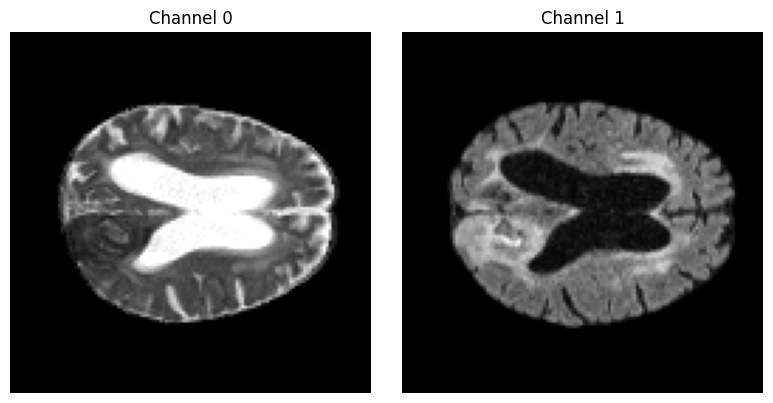

In [12]:
batch = next(iter(ano_dataset.test_anomaly_large_loader_metrics))
print("Batch shape:", batch.shape)

first_image = batch[0]
print("First image shape:", first_image.shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(first_image[0,...,64].cpu().numpy(), cmap="gray")
axes[0].set_title("Channel 0")
axes[0].axis("off")
axes[1].imshow(first_image[1,...,64].cpu().numpy(), cmap="gray")
axes[1].set_title("Channel 1")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### inference on SOOP images

**!! est ce qu'on met le même niveau de bruit sur FLAIR et ADC ?**

In [13]:
if args.noise["type"] == "simplex":
    infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(num_train_timesteps=args.noise["num_timesteps_full_noise"], schedule=args.noise["schedule"], octaves=args.noise["simplex_octaves"], persistence=args.noise["simplex_persistence"], frequency=args.noise["simplex_frequency"], normalize=args.noise["normalize"])

elif args.noise["type"] == "gaussian":
    infer_scheduler = DDPMScheduler(num_train_timesteps=args.noise["num_timesteps_full_noise"], schedule=args.noise["schedule"])


In [14]:
timesteps = 100

In [15]:
for i, image_batch in enumerate(ano_dataset.test_anomaly_large_loader_metrics):

    if i > 0:
        break

    test_images = image_batch.to(device)
    infered_slices = []
    
    # infer slice by slice
    for slice_idx in tqdm(range(args.slice_indexes_start, args.slice_indexes_end), ncols=70):

        infered_slice = my_sample(args, model, device, test_images[...,slice_idx], infer_scheduler, timesteps=timesteps, return_intermediates=False)
        infered_slices.append(infered_slice.unsqueeze(-1))

    # stack the slices back to a 3D volume
    final_average_infered_image = torch.zeros_like(test_images)
    average_infered_image_cat = torch.cat(infered_slices, dim=-1)

    final_average_infered_image[...,args.slice_indexes_start:args.slice_indexes_end] = average_infered_image_cat
    



100%|█████████████████████████████████| 72/72 [07:46<00:00,  6.48s/it]


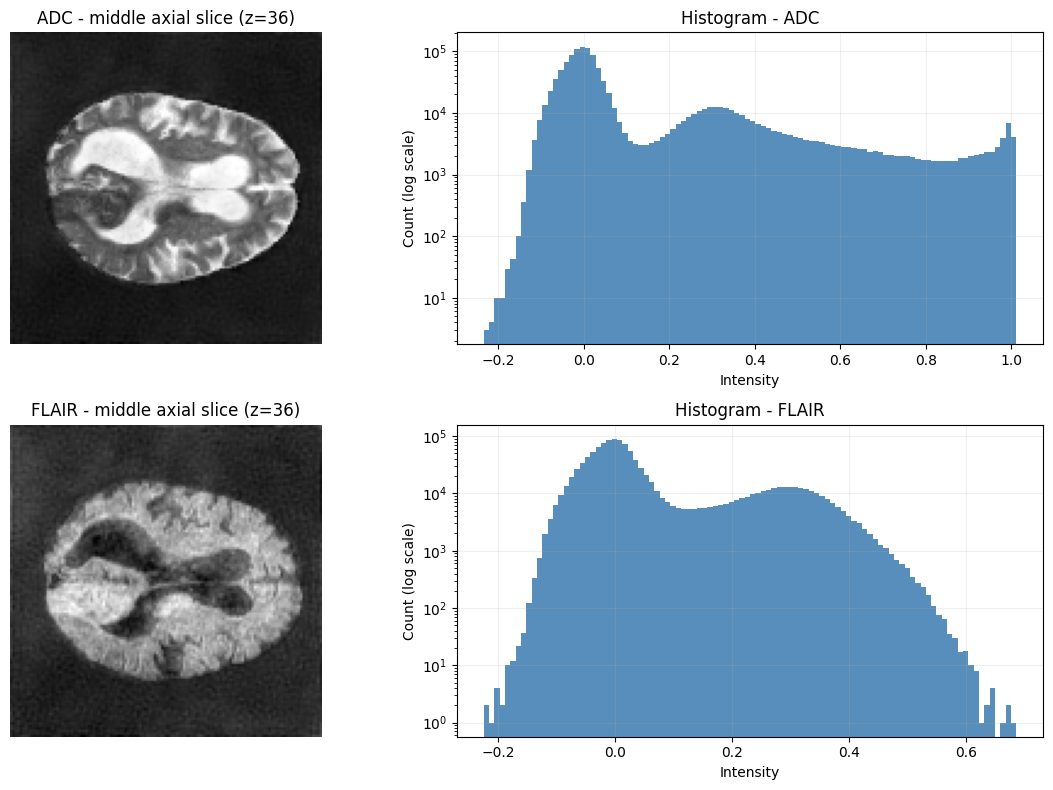

In [16]:
# Histograms + middle axial slice per channel for one inferred image
image_idx = 0  # change if needed
channel_names = {0: "ADC", 1: "FLAIR"}

infer_vol = average_infered_image_cat[image_idx].detach().float().cpu()  # [C, H, W, Z]
mid_z = infer_vol.shape[-1] // 2

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ch in range(2):
    # Middle axial slice
    mid_slice = infer_vol[ch, :, :, mid_z].numpy()
    axes[ch, 0].imshow(mid_slice, cmap="gray")
    axes[ch, 0].set_title(f"{channel_names.get(ch, f'Channel {ch}')} - middle axial slice (z={mid_z})")
    axes[ch, 0].axis("off")

    # Histogram over full 3D channel volume
    vals = infer_vol[ch].numpy().ravel()
    axes[ch, 1].hist(vals, bins=100, color="steelblue", alpha=0.9)
    axes[ch, 1].set_yscale("log")
    axes[ch, 1].set_title(f"Histogram - {channel_names.get(ch, f'Channel {ch}')}")
    axes[ch, 1].set_xlabel("Intensity")
    axes[ch, 1].set_ylabel("Count (log scale)")
    axes[ch, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [17]:
# histogram scaling on each channel of each image from the batch separately
for image_idx in range(final_average_infered_image.shape[0]):
    for channel in range(final_average_infered_image.shape[1]):
        final_average_infered_image[image_idx,channel,...] = torch.clamp(scale_intensity_from_histogram_peak(final_average_infered_image[image_idx,channel,...], target_value=2.0/7.0, min_search_value=0.12), 0.0, 1.0)


# make the anomaly map (difference between infered and original)
final_anomaly_map = torch.abs(final_average_infered_image - test_images)

In [18]:
print(f"average_infered_image shape: {final_average_infered_image.shape}")

average_infered_image shape: torch.Size([1, 2, 128, 128, 128])


test_images shape: torch.Size([1, 2, 128, 128, 128])


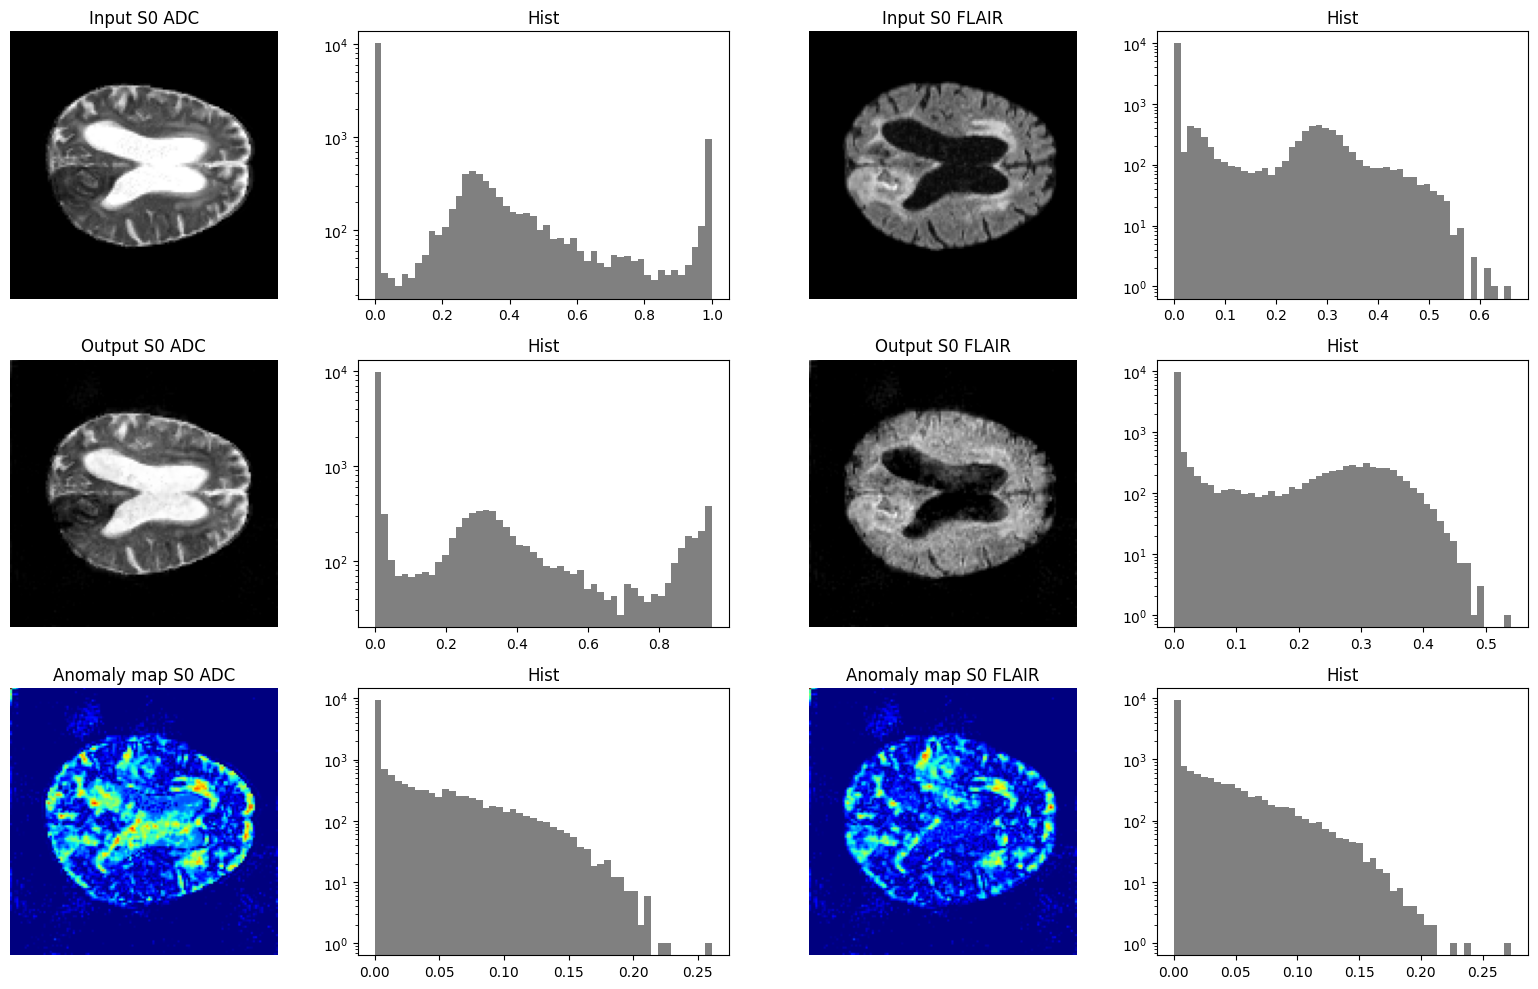

In [19]:
n_show = min(4, test_images.shape[0])
channels_to_show = [0, 1]  # 0=ADC, 1=FLAIR
channel_names = {0: "ADC", 1: "FLAIR"}
mid_z = test_images.shape[-1] // 2

n_img_cols = n_show * len(channels_to_show)
# for each image panel: one column for image + one column for histogram
fig, axes = plt.subplots(3, n_img_cols * 2, figsize=(4 * n_img_cols * 2, 10))

print(f"test_images shape: {test_images.shape}")

for i in range(n_show):
    for j, ch in enumerate(channels_to_show):
        base_col = (i * len(channels_to_show) + j) * 2
        img_col = base_col
        hist_col = base_col + 1

        inp = test_images[i, ch, :, :, mid_z].detach().cpu().numpy()
        out = final_average_infered_image[i, ch, :, :, mid_z].detach().cpu().numpy()
        ano = final_anomaly_map[i, ch, :, :, mid_z].detach().cpu().numpy()

        # Row 0: input + hist
        axes[0, img_col].imshow(inp, cmap="gray")
        axes[0, img_col].set_title(f"Input S{i} {channel_names[ch]}")
        axes[0, img_col].axis("off")
        axes[0, hist_col].hist(inp.ravel(), bins=50, color="gray")
        axes[0, hist_col].set_title("Hist")
        axes[0, hist_col].set_yscale("log")

        # Row 1: output + hist
        axes[1, img_col].imshow(out, cmap="gray")
        axes[1, img_col].set_title(f"Output S{i} {channel_names[ch]}")
        axes[1, img_col].axis("off")
        axes[1, hist_col].hist(out.ravel(), bins=50, color="gray")
        axes[1, hist_col].set_title("Hist")
        axes[1, hist_col].set_yscale("log")

        # Row 2: anomaly + hist
        axes[2, img_col].imshow(ano, cmap="jet")
        axes[2, img_col].set_title(f"Anomaly map S{i} {channel_names[ch]}")
        axes[2, img_col].axis("off")
        axes[2, hist_col].hist(ano.ravel(), bins=50, color="gray")
        axes[2, hist_col].set_title("Hist")
        axes[2, hist_col].set_yscale("log")

plt.tight_layout()
plt.show()